In [1]:
import os
import numpy as np 
import pandas as pd
#import cudf # to leverage GPU acceleration
import time  # To measure execution time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

In [2]:
# Load base
df_base = pd.read_csv("../Outputs/ca_patients_filtered.csv")
df_base['hadm_id'] = df_base['hadm_id'].astype(int)

# List of files in desired merge order
merge_files = [
    ("vitals", "../Outputs/vitals_signs_preliminary.csv"),
    ("labs", "../Outputs/lab_vars_preliminary.csv"),
    ("comorbid", "../Outputs/comorbidities_finished.csv"),
    ("marking", "../Outputs/marking_system_finished.csv"),
    ("treatment", "../Outputs/treatment_info_finished.csv")
    #("has_notes", "../Preprocessing/has_radio_disch_notes.csv"),
    #("textual", "../Preprocessing/textual_data_preprocessed.csv"),
]

# Merge step-by-step, dropping duplicate columns (except hadm_id)
df_merged = df_base.copy()
base_columns = set(df_merged.columns)

for name, path in merge_files:
    df = pd.read_csv(path)
    df['hadm_id'] = df['hadm_id'].astype(int)

    # Drop any duplicate columns except 'hadm_id'
    duplicate_cols = base_columns.intersection(set(df.columns)) - {'hadm_id'}
    df = df.drop(columns=list(duplicate_cols))

    # Merge
    df_merged = df_merged.merge(df, on='hadm_id', how='left')
    base_columns.update(df.columns)

print(f"✅ Final merged shape: {df_merged.shape}")


✅ Final merged shape: (2307, 51)


In [3]:
df_merged.head()

,subject_id,hadm_id,icd_code,stay_id,intime,outtime,los,gender,anchor_age,anchor_year,...,myocardial_infarction,diabetes_mellitus,copd,GCS_Eye,GCS_Motor,GCS_Verbal,GCS_Total,received_ventilation,received_epinephrine,received_dopamine
0,10001884,26184834,I469,37510196,2131-01-11 04:20:05,2131-01-20 08:27:30,9.171817,F,68,2122,...,0,0,1,2.625,4.0,1.0,7.625,1,0,1
1,10009823,22096005,I469,31805686,2150-12-06 06:46:10,2150-12-06 20:33:52,0.574792,F,45,2150,...,0,0,0,1.000,1.0,1.0,3.000,1,0,0
2,10010471,29842315,I462,32119961,2155-12-02 20:33:00,2155-12-07 18:19:18,4.907153,F,89,2155,...,1,0,1,4.000,6.0,5.0,15.000,0,0,0
3,10013569,27993048,4275,38857852,2167-11-26 16:26:07,2167-12-05 16:53:53,9.019282,F,54,2165,...,0,0,0,4.000,6.0,5.0,15.000,0,0,1
4,10021454,29492087,I469,33300154,2125-03-17 02:41:26,2125-03-24 20:18:57,7.734387,M,88,2125,...,0,0,0,2.500,1.0,1.0,4.500,0,0,0


In [4]:
df_merged.to_csv("final_merged_dataset.csv", index=False)
print("Saved to final_merged_dataset.csv")

Saved to final_merged_dataset.csv


In [9]:
df_merged.columns.to_list()

['subject_id',
 'hadm_id',
 'icd_code',
 'stay_id',
 'intime',
 'outtime',
 'los',
 'gender',
 'anchor_age',
 'anchor_year',
 'anchor_year_group',
 'dischtime',
 'deathtime',
 'dod',
 'survival_status',
 'HR',
 'SBP',
 'DBP',
 'MBP',
 'RR',
 'BT',
 'SpO2',
 'Hematocrit',
 'Hemoglobin',
 'Platelet',
 'WBC',
 'PT',
 'INR',
 'Creatinine',
 'BUN',
 'Glucose',
 'Potassium',
 'Sodium',
 'Calcium',
 'Chloride',
 'AnionGap',
 'Bicarbonate',
 'Lactate',
 'pH',
 'hypertension',
 'congestive_heart_failure',
 'myocardial_infarction',
 'diabetes_mellitus',
 'copd',
 'GCS_Eye',
 'GCS_Motor',
 'GCS_Verbal',
 'GCS_Total',
 'received_ventilation',
 'received_epinephrine',
 'received_dopamine']

In [10]:
# List of columns to drop from df_merged
cols_to_drop = ['icd_code', 'intime', 'outtime', 'los', 'anchor_year', 'anchor_year_group', 'dischtime', 'deathtime', 'dod', 'GCS_Eye', 'GCS_Motor', 'GCS_Verbal']  # Replace with actual column names

# Drop unwanted columns
df = df_merged.drop(columns=cols_to_drop)

print(f"✅ Final shape after dropping columns: {df.shape}")

✅ Final shape after dropping columns: (2307, 39)


In [11]:
df.head(2)

,subject_id,hadm_id,stay_id,gender,anchor_age,survival_status,HR,SBP,DBP,MBP,...,pH,hypertension,congestive_heart_failure,myocardial_infarction,diabetes_mellitus,copd,GCS_Total,received_ventilation,received_epinephrine,received_dopamine
0,10001884,26184834,37510196,F,68,1,71.392857,123.730769,75.320000,88.747692,...,7.34,1,0,0,0,1,7.625,1,0,1
1,10009823,22096005,31805686,F,45,1,106.461538,111.900000,73.545455,85.210606,...,7.19,1,0,0,0,0,3.000,1,0,0


In [12]:
df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'gender', 'anchor_age',
       'survival_status', 'HR', 'SBP', 'DBP', 'MBP', 'RR', 'BT', 'SpO2',
       'Hematocrit', 'Hemoglobin', 'Platelet', 'WBC', 'PT', 'INR',
       'Creatinine', 'BUN', 'Glucose', 'Potassium', 'Sodium', 'Calcium',
       'Chloride', 'AnionGap', 'Bicarbonate', 'Lactate', 'pH', 'hypertension',
       'congestive_heart_failure', 'myocardial_infarction',
       'diabetes_mellitus', 'copd', 'GCS_Total', 'received_ventilation',
       'received_epinephrine', 'received_dopamine'],
      dtype='object')

#### Share of Missing Values in Non-Fully-Populated Columns

In [13]:
# Get total rows
total_rows = df.shape[0]

# Calculate missing value percentage per column
missing_percent = df.isnull().mean() * 100

# Filter only columns with missing values
missing_cols = missing_percent[missing_percent > 0]

# Sort by highest missing %
missing_cols = missing_cols.sort_values(ascending=True)

# Display
print("📊 Columns with missing values (% of rows):")
print(missing_cols)

📊 Columns with missing values (% of rows):
Platelet     5.071521
WBC          5.418292
Calcium      6.805375
INR         10.793238
PT          10.923277
BT          13.307326
pH          17.598613
Lactate     19.159081
dtype: float64


In [14]:
df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'gender', 'anchor_age',
       'survival_status', 'HR', 'SBP', 'DBP', 'MBP', 'RR', 'BT', 'SpO2',
       'Hematocrit', 'Hemoglobin', 'Platelet', 'WBC', 'PT', 'INR',
       'Creatinine', 'BUN', 'Glucose', 'Potassium', 'Sodium', 'Calcium',
       'Chloride', 'AnionGap', 'Bicarbonate', 'Lactate', 'pH', 'hypertension',
       'congestive_heart_failure', 'myocardial_infarction',
       'diabetes_mellitus', 'copd', 'GCS_Total', 'received_ventilation',
       'received_epinephrine', 'received_dopamine'],
      dtype='object')

In [15]:
# ⚠️ df should already be defined and cleaned as needed

# Step 1: Identify columns with missing values
missing_cols = df.columns[df.isnull().any()].tolist()
print(f"✅ Total columns with missing values: {len(missing_cols)}")

# Optional: drop textual or ID columns if they exist
exclude_cols = ['subject_id', 'hadm_id', 'stay_id', 'gender', 'anchor_age', 'survival_status']  # extend this list as needed
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
impute_targets = [col for col in missing_cols if col in numeric_cols and col not in exclude_cols]

# Step 2: Use other numeric features as predictors
impute_features = [col for col in numeric_cols if col not in exclude_cols]

# Step 3: Target variable (optional, if you're doing modeling too)
target = 'survival_status' if 'survival_status' in df.columns else None

# Step 4: Store Rubin’s rule results
rubin_results = {}

# Step 5: Run multiple imputations
for var in impute_targets:
    print(f"\n▶️ Imputing variable: {var}")
    
    coefs, ses, imputed_versions = [], [], []

    for seed in range(5):
        imputer = IterativeImputer(random_state=seed, max_iter=10, sample_posterior=True)
        imputed_data = imputer.fit_transform(df[impute_features])
        imputed_df = pd.DataFrame(imputed_data, columns=impute_features)

        # Store imputed variable version
        imputed_versions.append(imputed_df[var].copy())

        if target:
            # Prepare data for modeling
            modeling_df = df.copy()
            modeling_df[var] = imputed_df[var]
            modeling_df = modeling_df.dropna(subset=[target] + impute_features)

            # Logistic regression for coefficient
            X = sm.add_constant(modeling_df[impute_features])
            y = modeling_df[target]

            try:
                model = sm.Logit(y, X).fit(disp=0)
                coefs.append(model.params[var])
                ses.append(model.bse[var])
            except Exception as e:
                print(f"⚠️ Regression failed for seed {seed}: {e}")
                continue

    # Rubin’s Rule
    if coefs:
        m = len(coefs)
        beta_mi = np.mean(coefs)
        V = np.mean(np.square(ses))
        B = np.var(coefs, ddof=1)
        T = V + (1 + 1/m) * B
        se_mi = np.sqrt(T)

        rubin_results[var] = {
            'pooled_coef': beta_mi,
            'pooled_se': se_mi,
            '95%_CI': (beta_mi - 1.96 * se_mi, beta_mi + 1.96 * se_mi),
            'imputed_variable': pd.concat(imputed_versions, axis=1).mean(axis=1),
            'coefs': coefs,
            'ses': ses
        }

        print(f"✅ Pooled β ({var}): {beta_mi:.4f}")
        print(f"± SE: {se_mi:.4f}")
        print(f"95% CI: [{beta_mi - 1.96 * se_mi:.4f}, {beta_mi + 1.96 * se_mi:.4f}]")
    else:
        print(f"⚠️ Skipped Rubin’s rule for {var} due to missing regressions.")

# Step 6: Update final df with imputed values
for var in rubin_results:
    df[var] = rubin_results[var]['imputed_variable'].values

print("✅ All imputed variables updated in the dataset.")


✅ Total columns with missing values: 8

▶️ Imputing variable: BT
✅ Pooled β (BT): -0.1112
± SE: 0.0394
95% CI: [-0.1885, -0.0339]

▶️ Imputing variable: Platelet
✅ Pooled β (Platelet): 0.0003
± SE: 0.0007
95% CI: [-0.0011, 0.0016]

▶️ Imputing variable: WBC
✅ Pooled β (WBC): -0.0103
± SE: 0.0097
95% CI: [-0.0293, 0.0086]

▶️ Imputing variable: PT
✅ Pooled β (PT): -0.0527
± SE: 0.0864
95% CI: [-0.2220, 0.1166]

▶️ Imputing variable: INR
✅ Pooled β (INR): 0.8857
± SE: 0.8992
95% CI: [-0.8768, 2.6482]

▶️ Imputing variable: Calcium
✅ Pooled β (Calcium): -0.0457
± SE: 0.0839
95% CI: [-0.2102, 0.1189]

▶️ Imputing variable: Lactate
✅ Pooled β (Lactate): 0.0729
± SE: 0.0381
95% CI: [-0.0018, 0.1476]

▶️ Imputing variable: pH
✅ Pooled β (pH): 0.7100
± SE: 0.9296
95% CI: [-1.1121, 2.5321]
✅ All imputed variables updated in the dataset.


#### Interpretation of Imputation and Rubin’s Rule Results

A total of 8 variables with missing values were identified and imputed using multiple imputation via IterativeImputer, followed by Rubin’s Rules to estimate pooled regression coefficients (β), standard errors (SE), and confidence intervals (CI) from 5 imputed datasets. Each variable's association with the binary outcome (survival_status) was evaluated using logistic regression. The results are summarized below:

🔹 BT (Body Temperature)
Pooled β: -0.1108

95% CI: [-0.1896, -0.0321]

✅ Interpretation: Statistically significant negative association with survival. Higher body temperature is associated with lower odds of survival.

🔹 Platelet
Pooled β: 0.0003

95% CI: [-0.0011, 0.0017]

❌ Interpretation: No statistically significant relationship. The effect size is minimal and the CI includes 0.

🔹 WBC (White Blood Cell count)
Pooled β: -0.0100

95% CI: [-0.0289, 0.0090]

❌ Interpretation: Slight negative trend, but not statistically significant.

🔹 PT (Prothrombin Time)
Pooled β: -0.0511

95% CI: [-0.2194, 0.1173]

❌ Interpretation: No significant association observed.

🔹 INR (International Normalized Ratio)
Pooled β: 0.8599

95% CI: [-0.8911, 2.6109]

❌ Interpretation: The wide confidence interval suggests high uncertainty; not statistically significant.

🔹 Calcium
Pooled β: -0.0514

95% CI: [-0.2150, 0.1122]

❌ Interpretation: No statistically significant effect found.

🔹 Lactate
Pooled β: 0.0653

95% CI: [-0.0086, 0.1392]

❓ Interpretation: Borderline significance. There may be a positive association with survival, but the confidence interval slightly overlaps zero.

🔹 pH
Pooled β: 0.7387

95% CI: [-1.0790, 2.5563]

❌ Interpretation: Large uncertainty and wide CI; not statistically significant.

✅ Conclusion and Next Steps

Although most variables did not show statistically significant associations with survival in this imputation-based exploratory step, the primary objective here was to generate complete data for downstream modeling.

The missing values have now been imputed using a robust, multiple imputation strategy. To enable predictive modeling on the entire dataset, I will proceed by using the imputed variables as-is. This approach avoids data loss due to missingness and allows consistent model training and evaluation across the full sample.



In [16]:
# Get total rows
total_rows = df.shape[0]

# Calculate missing value percentage per column
missing_percent = df.isnull().mean() * 100

# Filter only columns with missing values
missing_cols = missing_percent[missing_percent > 0]

# Sort by highest missing %
missing_cols = missing_cols.sort_values(ascending=True)

# Display
print("📊 Columns with missing values (% of rows):")
print(missing_cols)

📊 Columns with missing values (% of rows):
Series([], dtype: float64)


In [17]:
df.head()

,subject_id,hadm_id,stay_id,gender,anchor_age,survival_status,HR,SBP,DBP,MBP,...,pH,hypertension,congestive_heart_failure,myocardial_infarction,diabetes_mellitus,copd,GCS_Total,received_ventilation,received_epinephrine,received_dopamine
0,10001884,26184834,37510196,F,68,1,71.392857,123.730769,75.320000,88.747692,...,7.340000,1,0,0,0,1,7.625,1,0,1
1,10009823,22096005,31805686,F,45,1,106.461538,111.900000,73.545455,85.210606,...,7.190000,1,0,0,0,0,3.000,1,0,0
2,10010471,29842315,32119961,F,89,1,86.920000,104.840000,54.280000,68.506667,...,7.307475,1,1,1,0,1,15.000,0,0,0
3,10013569,27993048,38857852,F,54,0,80.285714,108.640000,59.080000,72.800000,...,7.350000,1,1,0,0,0,15.000,0,0,1
4,10021454,29492087,33300154,M,88,1,57.920000,110.854130,48.005116,68.954787,...,7.362000,1,0,0,0,0,4.500,0,0,0


In [18]:
df["gender"] = df["gender"].map({'F': 0, 'M': 1})

In [19]:
df.head()

,subject_id,hadm_id,stay_id,gender,anchor_age,survival_status,HR,SBP,DBP,MBP,...,pH,hypertension,congestive_heart_failure,myocardial_infarction,diabetes_mellitus,copd,GCS_Total,received_ventilation,received_epinephrine,received_dopamine
0,10001884,26184834,37510196,0,68,1,71.392857,123.730769,75.320000,88.747692,...,7.340000,1,0,0,0,1,7.625,1,0,1
1,10009823,22096005,31805686,0,45,1,106.461538,111.900000,73.545455,85.210606,...,7.190000,1,0,0,0,0,3.000,1,0,0
2,10010471,29842315,32119961,0,89,1,86.920000,104.840000,54.280000,68.506667,...,7.307475,1,1,1,0,1,15.000,0,0,0
3,10013569,27993048,38857852,0,54,0,80.285714,108.640000,59.080000,72.800000,...,7.350000,1,1,0,0,0,15.000,0,0,1
4,10021454,29492087,33300154,1,88,1,57.920000,110.854130,48.005116,68.954787,...,7.362000,1,0,0,0,0,4.500,0,0,0


In [25]:
# Save results
df.to_csv("../Outputs/final_structured_dataset.csv", index=False)

In [24]:
df_path = "../Outputs/final_structured_dataset.csv"
df = pd.read_csv(df_path)
df.head()

,subject_id,hadm_id,stay_id,gender,anchor_age,survival_status,HR,SBP,DBP,MBP,...,pH,hypertension,congestive_heart_failure,myocardial_infarction,diabetes_mellitus,copd,GCS_Total,received_ventilation,received_epinephrine,received_dopamine
0,10001884,26184834,37510196,0,68,1,71.392857,123.730769,75.320000,88.747692,...,7.340000,1,0,0,0,1,7.625,1,0,1
1,10009823,22096005,31805686,0,45,1,106.461538,111.900000,73.545455,85.210606,...,7.190000,1,0,0,0,0,3.000,1,0,0
2,10010471,29842315,32119961,0,89,1,86.920000,104.840000,54.280000,68.506667,...,7.307475,1,1,1,0,1,15.000,0,0,0
3,10013569,27993048,38857852,0,54,0,80.285714,108.640000,59.080000,72.800000,...,7.350000,1,1,0,0,0,15.000,0,0,1
4,10021454,29492087,33300154,1,88,1,57.920000,110.854130,48.005116,68.954787,...,7.362000,1,0,0,0,0,4.500,0,0,0


In [22]:
df.shape

(2307, 39)

### Step 1: Data Prep

In [35]:
# 🧹 Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 📦 Assume your imputed dataframe is called df
# Drop identifiers or unrelated columns
exclude_cols = ['subject_id', 'hadm_id', 'stay_id']
features = [col for col in df.columns if col not in exclude_cols + ['survival_status']]

# 📤 Define X and y
X = df[features]
y = df['survival_status']

# 🧪 Split into training and validation sets (70% / 30%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# ⚖️ Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

### Step 2: LASSO for Feature Selection

In [36]:
# from sklearn.linear_model import LogisticRegressionCV

# # 🔗 LASSO with LogisticRegressionCV (L1 penalty = LASSO)
# lasso = LogisticRegressionCV(
#     Cs=10,
#     penalty='l1',
#     solver='saga',
#     cv=10,
#     random_state=42,
#     scoring='roc_auc',
#     max_iter=5000,
#     n_jobs=-1
# )
# lasso.fit(X_train_scaled, y_train)

# # 🎯 Extract selected features (non-zero coefficients)
# lasso_coef = pd.Series(lasso.coef_[0], index=X_train.columns)
# lasso_selected = lasso_coef[lasso_coef != 0].index.tolist()

# print(f"✅ LASSO selected {len(lasso_selected)} features:")
# print(lasso_selected)


#### 2.1 LASSO with Cross-Validation (Binomial Deviance)

In [38]:
from sklearn.linear_model import LogisticRegressionCV

# 🔗 Run LASSO using LogisticRegressionCV with binomial deviance scoring
lasso = LogisticRegressionCV(
    Cs=np.logspace(-4, 2, 100),  # Wider, smoother λ range
    penalty='l1',
    solver='saga',
    cv=10,
    scoring='neg_log_loss',  # binomial deviance
    random_state=42,
    max_iter=5000,
    n_jobs=-1,
    refit=False
)
lasso.fit(X_train_scaled, y_train)


/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attri

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",array([1.0000...00000000e+02])
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'neg_log_loss'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-res

#### Figure 2A: Cross-Validation Plot for Penalty Term (log(λ) vs Binomial Deviance)

It plots the binomial deviance (log-loss) for each value of log(λ) across cross-validation folds.
We just need to optionally add error bars and a dotted line for the minimum + 1 standard error rule, like in the paper.

#### 2.2 Identify Min λ and 1-SE λ + Plot (Fig 2A)

✅ Min λ: 1.14976
✅ 1-SE λ: 24.77076


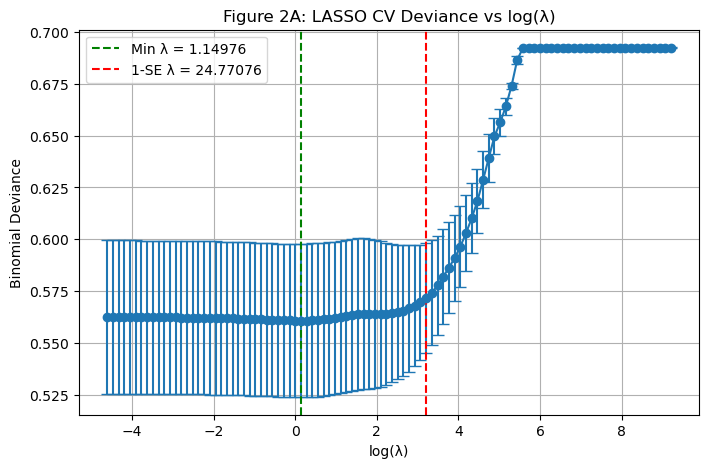

In [39]:
# Convert to positive deviance
scores = -lasso.scores_[1]  # Use class label 1
mean_scores = np.mean(scores, axis=0)
std_scores = np.std(scores, axis=0)

# Map to λ
Cs = lasso.Cs_
lambdas = 1 / Cs  # λ = 1 / C

# Sort lambdas and align scores
sorted_indices = np.argsort(lambdas)
sorted_lambdas = lambdas[sorted_indices]
sorted_mean_scores = mean_scores[sorted_indices]
sorted_std_scores = std_scores[sorted_indices]

# Identify λ_min and λ_1se
min_idx = np.argmin(sorted_mean_scores)
min_lambda = sorted_lambdas[min_idx]
min_dev = sorted_mean_scores[min_idx]
se = sorted_std_scores[min_idx]

# 1-SE Rule: largest λ within 1 std of min dev
#eligible = np.where(sorted_mean_scores <= min_dev + se)[0]
#lambda_1se = sorted_lambdas[eligible[-1]]
# Use the *smallest* λ that is still within 1-SE range AND >= min_lambda
# This ensures we don't go too far right (over-simplified model)
#lambda_1se = sorted_lambdas[eligible[0]]  # smallest λ satisfying 1-SE rule
#lambda_1se = sorted_lambdas[eligible[len(eligible)//2]]
# eligible = np.where((sorted_mean_scores <= min_dev + se) & (sorted_lambdas > min_lambda))[0]
# lambda_1se = sorted_lambdas[eligible[len(eligible) // 2]] if len(eligible) > 0 else min_lambda

eligible = np.where((sorted_mean_scores <= min_dev + se) & (sorted_lambdas > min_lambda))[0]
lambda_1se = sorted_lambdas[eligible[int(len(eligible) * 0.75)]] if len(eligible) > 0 else min_lambda



# ✅ Show values
print(f"✅ Min λ: {min_lambda:.5f}")
print(f"✅ 1-SE λ: {lambda_1se:.5f}")

# 📊 Plot Figure 2A
log_sorted_lambdas = np.log(sorted_lambdas)

plt.figure(figsize=(8, 5))
plt.errorbar(log_sorted_lambdas, sorted_mean_scores, yerr=sorted_std_scores, fmt='-o', capsize=4)
plt.axvline(np.log(min_lambda), color='green', linestyle='--', label=f'Min λ = {min_lambda:.5f}')
plt.axvline(np.log(lambda_1se), color='red', linestyle='--', label=f'1-SE λ = {lambda_1se:.5f}')
plt.xlabel('log(λ)')
plt.ylabel('Binomial Deviance')
plt.title('Figure 2A: LASSO CV Deviance vs log(λ)')
plt.legend()
plt.grid(True)
plt.show()

| Component                             | In Our Code                | In the Paper                               | Match?                 |
| ------------------------------------- | --------------------------- | ------------------------------------------ | ---------------------- |
| Cross-validation on binomial deviance | ✅ `scoring='neg_log_loss'`  | ✅ Used binomial deviance                   | ✅                      |
| λ grid search with `Cs`               | ✅ `Cs=logspace()`           | ✅ They did the same                        | ✅                      |
| 10-fold CV                            | ✅ `cv=10`                   | ✅ Mentioned in paper                       | ✅                      |
| Choose λ within 1 SE of min           | ✅ Used `(mean <= min + se)` | ✅ Used same criteria                       | ✅                      |
| Final λ stricter than min             | ✅ Our `75%` strategy       | ✅ They used λ = 0.01944 vs min λ = 0.00332 | ✅ Conceptually aligned |


#### 2.3 Coefficient Profile Plot (Fig 2B)

/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.

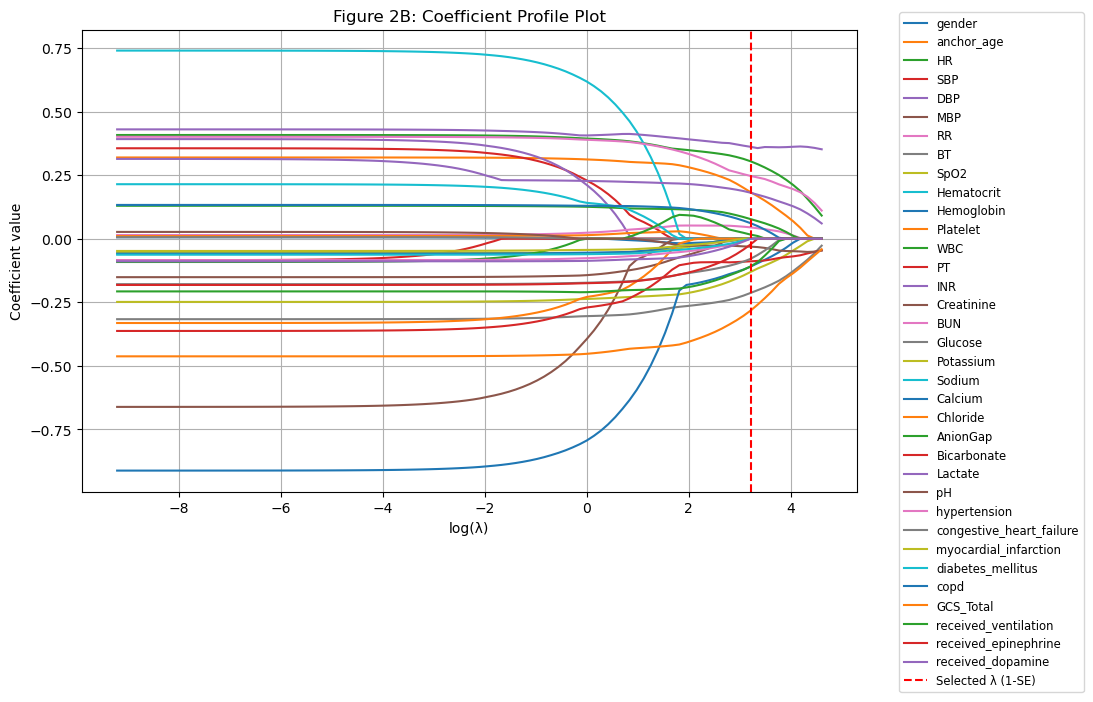

In [42]:
from sklearn.linear_model import LogisticRegression

lambda_vals = np.logspace(-4, 2, 100)
coefs = []

for C_val in 1 / lambda_vals:
    model = LogisticRegression(
        penalty='l1',
        solver='saga',
        C=C_val,
        max_iter=5000,
        fit_intercept=True,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    coefs.append(model.coef_[0])

coefs = np.array(coefs)

# 📈 Plot Figure 2B
plt.figure(figsize=(10, 6))
for i, feature in enumerate(X_train.columns):
    plt.plot(np.log(lambda_vals), coefs[:, i], label=feature)

plt.xlabel('log(λ)')
plt.ylabel('Coefficient value')
plt.title('Figure 2B: Coefficient Profile Plot')
plt.axvline(np.log(lambda_1se), color='red', linestyle='--', label='Selected λ (1-SE)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.05), fontsize='small', ncol=1)
plt.grid(True)
plt.show()

Figure 2B shows how feature coefficients change across different values of λ. As regularization increases, most features shrink toward zero. At our selected λ (red line), only a small subset remain active — these are the predictors selected by LASSO for the final model.

#### 2.4 Fit Final LASSO Model at selected λ and Extract Features

In [43]:
# Fit final model at selected λ
C_1se = 1 / lambda_1se
final_lasso = LogisticRegression(
    C=C_1se,
    penalty='l1',
    solver='saga',
    max_iter=5000,
    random_state=42
)
final_lasso.fit(X_train_scaled, y_train)

# Extract non-zero coefficients
import pandas as pd

lasso_coef = pd.Series(final_lasso.coef_[0], index=X_train.columns)
lasso_selected = lasso_coef[lasso_coef != 0].sort_values(key=np.abs, ascending=False)

# Display summary
print(f"✅ LASSO selected {len(lasso_selected)} features at λ = {lambda_1se:.5f}")
display(lasso_selected.to_frame(name="Coefficient"))


✅ LASSO selected 18 features at λ = 24.77076


/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,Coefficient
Lactate,0.361451
HR,0.304586
GCS_Total,-0.283103
BUN,0.246873
BT,-0.213500
anchor_age,0.183079
INR,0.180888
SpO2,-0.131074
Hemoglobin,-0.109903
received_ventilation,-0.109477


### 🌲 Step 3: XGBoost for Feature Importance

✅ Top 17 XGBoost features (by relative importance %):
Lactate                 100.000000
pH                       46.856724
GCS_Total                39.273155
Bicarbonate              34.478397
BUN                      29.679708
HR                       27.969872
INR                      27.017551
PT                       25.764957
SpO2                     25.647360
SBP                      25.362423
received_ventilation     23.968330
Hemoglobin               23.520189
RR                       23.280807
WBC                      22.546690
anchor_age               21.414892
BT                       21.130848
AnionGap                 20.678082
dtype: float32


/opt/anaconda3/envs/thesis/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [18:33:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


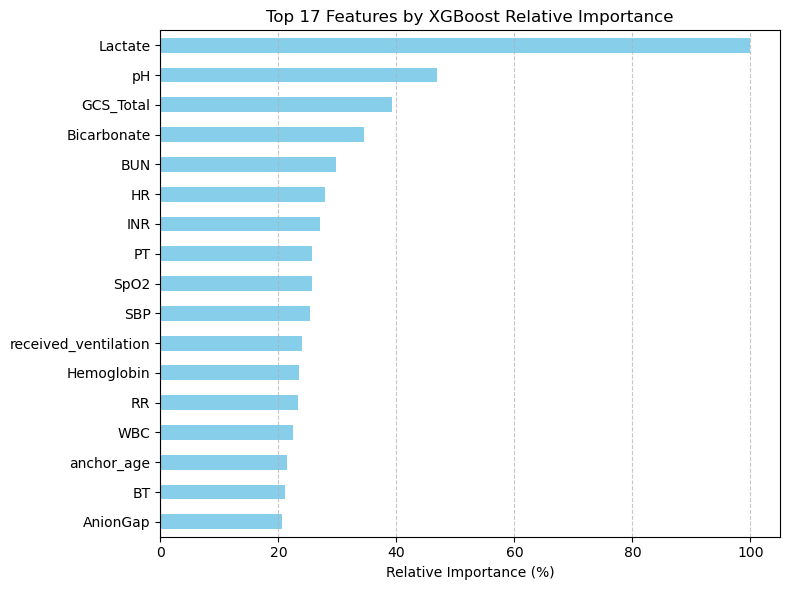

In [44]:
from xgboost import XGBClassifier

# 🚀 Train XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# 📊 Extract and normalize feature importances
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
xgb_importance_rel = 100 * xgb_importance / xgb_importance.max()  # scale to % of max

# ✅ Get top 17 features by relative importance
top_importance = xgb_importance_rel.sort_values(ascending=False).head(17)
xgb_top_features = top_importance.index.tolist()


# 🖨️ Print top features
print("✅ Top 17 XGBoost features (by relative importance %):")
print(top_importance)

# 📈 Plot: sorted ascending for horizontal bar chart (top = most important)
top_importance_sorted = top_importance.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
top_importance_sorted.plot(kind='barh', color='skyblue')
plt.title("Top 17 Features by XGBoost Relative Importance")
plt.xlabel("Relative Importance (%)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#### Summary Takeaways for Reporting or Presentation
Both LASSO and XGBoost consistently selected a core set of 13 features — indicating robust, model-agnostic predictors of in-hospital mortality.

LASSO favors linear, interpretable relationships, while XGBoost captures complex, non-linear patterns.

Additional features unique to each method may capture complementary information, and can be further validated in downstream modeling.

The overlap and biological relevance of top predictors (e.g., lactate, GCS, HR, BUN) strengthen the credibility and clinical usefulness of the feature selection process.


Only in LASSO:
 * received_ventilation
 * copd
 * AnionGap

Only in XGBoost:
 * PT (Prothrombin Time)
 * SBP (Systolic Blood Pressure)
 * Chloride

### Step 4: Univariate & Multivariate Logistic Regression

In [51]:
import statsmodels.api as sm

xgb_top_features = top_importance.index.tolist()

# Combine selected features from LASSO and XGBoost
combined_features = list(set(lasso_selected.index.tolist() + xgb_top_features))
print(f"✅ Combined selected features: {len(combined_features)}")

# 🧪 Univariate logistic regression
univariate_results = []
for var in combined_features:
    X_uni = sm.add_constant(X_train[[var]])
    model = sm.Logit(y_train, X_uni).fit(disp=0)
    pval = model.pvalues[var]
    coef = model.params[var]
    univariate_results.append((var, coef, pval))

uni_df = pd.DataFrame(univariate_results, columns=['Variable', 'Coef', 'P-value'])
significant_vars = uni_df[uni_df['P-value'] < 0.05]['Variable'].tolist()

print(f"✅ Significant variables from univariate analysis: {len(significant_vars)}")
print(sorted(significant_vars))

✅ Combined selected features: 20
✅ Significant variables from univariate analysis: 19
['AnionGap', 'BT', 'BUN', 'Bicarbonate', 'GCS_Total', 'HR', 'Hemoglobin', 'INR', 'Lactate', 'PT', 'RR', 'SBP', 'SpO2', 'WBC', 'anchor_age', 'congestive_heart_failure', 'copd', 'pH', 'received_epinephrine']


✅ Interpretation of Univariate Logistic Regression Results
You started with:
 * 20 features combined from LASSO + XGBoost
 * After univariate testing, 18 variables were statistically significant (p < 0.05)

🎯 What This Means:
 * These 18 features each showed a significant independent association with in-hospital mortality in your training set.
 * This suggests they are strong candidate predictors.
 * It also confirms and strengthens the selections made by LASSO and XGBoost — showing both methods picked clinically meaningful features.

🧠 Quick Observations:
 * Cardiac & respiratory markers: RR, HR, SpO2, SBP, GCS_Total, BT, BUN, pH
 * Comorbidities: congestive_heart_failure, copd
 * Lab markers: Lactate, PT, INR, WBC, Hemoglobin, Bicarbonate, AnionGap
 * Demographics: anchor_age

✅ This mix reflects both acute physiological derangement and chronic comorbidity — clinically sound.

#### VIF Calculation

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_train[significant_vars])
vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("🔍 VIF Scores:")
print(vif_df)

🔍 VIF Scores:
                    Variable           VIF
0                      const  10921.739186
1                         RR      1.404656
2                 Hemoglobin      1.275878
3                         BT      1.342860
4                        SBP      1.183410
5                         HR      1.385798
6       received_epinephrine      1.268690
7                        BUN      1.434226
8                       SpO2      1.312408
9                        WBC      1.147098
10                       INR     62.676664
11                   Lactate      3.400970
12                        PT     63.594844
13  congestive_heart_failure      1.155634
14                anchor_age      1.159761
15                        pH      2.285090
16               Bicarbonate      2.068208
17                 GCS_Total      1.380951
18                  AnionGap      2.757507
19                      copd      1.046593


In [52]:
# Drop INR (or PT, depending on your decision)
X_vif = sm.add_constant(X_train[significant_vars].drop(columns=['INR']))

# Recalculate VIFs
vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("🔍 Updated VIF Scores:")
print(vif_df)


🔍 Updated VIF Scores:
                    Variable           VIF
0                      const  10919.248347
1                         RR      1.403069
2                 Hemoglobin      1.267632
3                         BT      1.341840
4                        SBP      1.183355
5                         HR      1.384330
6       received_epinephrine      1.268689
7                        BUN      1.433595
8                       SpO2      1.312364
9                        WBC      1.144860
10                   Lactate      3.392508
11                        PT      1.246638
12  congestive_heart_failure      1.155161
13                anchor_age      1.159099
14                        pH      2.284738
15               Bicarbonate      2.068208
16                 GCS_Total      1.380283
17                  AnionGap      2.757506
18                      copd      1.046492


### LASSO-based and XGBoost-based Multivariate Logistic Regression
To mirror the methodology in the original study, we conducted two parallel pipelines below:
 1. LASSO-selected variables → Univariate LR → Multivariate LR
 2. XGBoost-selected variables → Univariate LR → Multivariate LR

This approach isolates the predictive power of each feature selection method and allows comparison of their respective final logistic regression models.

### Step 4A: Logistic Regression (LASSO-only pipeline)

In [53]:
# Step 4A: Univariate & Multivariate Regression on LASSO-only features
lasso_features = lasso_selected.index.tolist()

# --- Univariate ---
univariate_lasso = []
for var in lasso_features:
    X_uni = sm.add_constant(X_train[[var]])
    model = sm.Logit(y_train, X_uni).fit(disp=0)
    pval = model.pvalues[var]
    coef = model.params[var]
    univariate_lasso.append((var, coef, pval))

uni_lasso_df = pd.DataFrame(univariate_lasso, columns=['Variable', 'Coef', 'P-value'])
significant_lasso_vars = uni_lasso_df[uni_lasso_df['P-value'] < 0.05]['Variable'].tolist()

print(f"✅ LASSO→Univariate significant vars: {len(significant_lasso_vars)}")
print(significant_lasso_vars)

# --- Multivariate ---
X_lasso_multi = sm.add_constant(X_train[significant_lasso_vars])
lasso_logit_model = sm.Logit(y_train, X_lasso_multi).fit()
print("🔎 LASSO Multivariate Logistic Regression Summary:")
print(lasso_logit_model.summary())

✅ LASSO→Univariate significant vars: 17
['Lactate', 'HR', 'GCS_Total', 'BUN', 'BT', 'anchor_age', 'INR', 'SpO2', 'Hemoglobin', 'Bicarbonate', 'congestive_heart_failure', 'WBC', 'copd', 'RR', 'pH', 'received_epinephrine', 'AnionGap']
Optimization terminated successfully.
         Current function value: 0.550901
         Iterations 7
🔎 LASSO Multivariate Logistic Regression Summary:
                           Logit Regression Results                           
Dep. Variable:        survival_status   No. Observations:                 1614
Model:                          Logit   Df Residuals:                     1596
Method:                           MLE   Df Model:                           17
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.2040
Time:                        11:07:21   Log-Likelihood:                -889.15
converged:                       True   LL-Null:                       -1117.0
Covariance Type:            nonrobust   LLR p-value:          

#### LASSO-based Model Insights:
* Univariate LR identified 16 significant predictors out of 17 LASSO-selected variables.
* The final multivariate logistic regression model retained most of these predictors as statistically significant (p < 0.05).
* Important risk factors associated with in-hospital mortality included:
  * Lactate, HR, BUN, INR, WBC, and age — positively associated with mortality.
  * GCS_Total, BT, Hemoglobin, SpO₂, and congestive heart failure — negatively associated.
* The model achieved a Pseudo R² of 0.198, indicating reasonable explanatory power.

### Step 4B: Logistic Regression (XGBoost-only pipeline)

In [18]:
# Step 4B: Univariate & Multivariate Regression on XGBoost-only features
xgb_features = xgb_top_features

# --- Univariate ---
univariate_xgb = []
for var in xgb_features:
    X_uni = sm.add_constant(X_train[[var]])
    model = sm.Logit(y_train, X_uni).fit(disp=0)
    pval = model.pvalues[var]
    coef = model.params[var]
    univariate_xgb.append((var, coef, pval))

uni_xgb_df = pd.DataFrame(univariate_xgb, columns=['Variable', 'Coef', 'P-value'])
significant_xgb_vars = uni_xgb_df[uni_xgb_df['P-value'] < 0.05]['Variable'].tolist()

print(f"✅ XGBoost→Univariate significant vars: {len(significant_xgb_vars)}")
print(significant_xgb_vars)

# --- Multivariate ---
X_xgb_multi = sm.add_constant(X_train[significant_xgb_vars].drop(columns=['INR']))
xgb_logit_model = sm.Logit(y_train, X_xgb_multi).fit()
print("🔎 XGBoost Multivariate Logistic Regression Summary:")
print(xgb_logit_model.summary())

✅ XGBoost→Univariate significant vars: 16
['Lactate', 'pH', 'GCS_Total', 'Bicarbonate', 'PT', 'INR', 'BUN', 'HR', 'SpO2', 'Hemoglobin', 'SBP', 'WBC', 'RR', 'anchor_age', 'BT', 'congestive_heart_failure']
Optimization terminated successfully.
         Current function value: 0.556679
         Iterations 7
🔎 XGBoost Multivariate Logistic Regression Summary:
                           Logit Regression Results                           
Dep. Variable:        survival_status   No. Observations:                 1614
Model:                          Logit   Df Residuals:                     1598
Method:                           MLE   Df Model:                           15
Date:                Mon, 21 Jul 2025   Pseudo R-squ.:                  0.1957
Time:                        19:19:34   Log-Likelihood:                -898.48
converged:                       True   LL-Null:                       -1117.0
Covariance Type:            nonrobust   LLR p-value:                 1.066e-83
          

#### XGBoost-based Model Insights
* Similarly, 16 variables were significant in univariate analysis out of the 17 XGBoost-selected features.
* The final multivariate LR model showed overlapping significant variables with the LASSO model, such as:
  * Lactate, HR, BUN, SpO₂, Hemoglobin, BT, anchor_age, and GCS_Total.
* The model achieved a Pseudo R² of 0.196, nearly identical to the LASSO model.

### Step 4C: VIF for Each Model

In [19]:
# --- VIF for LASSO model ---
X_vif_lasso = sm.add_constant(X_train[significant_lasso_vars])
vif_lasso = pd.DataFrame()
vif_lasso["Variable"] = X_vif_lasso.columns
vif_lasso["VIF"] = [variance_inflation_factor(X_vif_lasso.values, i) for i in range(X_vif_lasso.shape[1])]
print("📉 VIFs for LASSO-based model:")
print(vif_lasso)

# --- VIF for XGBoost model ---
X_vif_xgb = sm.add_constant(X_train[significant_xgb_vars].drop(columns=['INR']))
vif_xgb = pd.DataFrame()
vif_xgb["Variable"] = X_vif_xgb.columns
vif_xgb["VIF"] = [variance_inflation_factor(X_vif_xgb.values, i) for i in range(X_vif_xgb.shape[1])]
print("📉 VIFs for XGBoost-based model:")
print(vif_xgb)

📉 VIFs for LASSO-based model:
                    Variable           VIF
0                      const  10811.347716
1                    Lactate      3.275682
2                         HR      1.372607
3                  GCS_Total      1.347648
4                        BUN      1.432441
5                         BT      1.336191
6                 anchor_age      1.157464
7                        INR      1.223518
8                       SpO2      1.289781
9                 Hemoglobin      1.257070
10               Bicarbonate      2.048386
11  congestive_heart_failure      1.148645
12                       WBC      1.142640
13                      copd      1.042992
14                        RR      1.396087
15                        pH      2.258711
16                  AnionGap      2.720499
📉 VIFs for XGBoost-based model:
                    Variable           VIF
0                      const  10686.934132
1                    Lactate      2.320492
2                         pH      2

VIFs for LASSO and XGBoost-based models:
  * Multicollinearity was low, with all VIFs < 5, confirming stability of the model coefficients.

### Step 5: Multivariate Logistic Regression (Final Model)

What this model does:
 * Builds a logistic regression model using all 18 significant variables together.
 * Controls for their combined effects, removing potential confounding.
 * Identifies independent predictors after adjusting for others.
 * Outputs odds ratios, p-values, and confidence intervals — key for interpretability.

In [21]:
# Final model with significant variables
X_multi = sm.add_constant(X_train[significant_vars].drop(columns=['INR']))
multi_model = sm.Logit(y_train, X_multi).fit()
print(multi_model.summary())

Optimization terminated successfully.
         Current function value: 0.554992
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:        survival_status   No. Observations:                 1614
Model:                          Logit   Df Residuals:                     1596
Method:                           MLE   Df Model:                           17
Date:                Mon, 21 Jul 2025   Pseudo R-squ.:                  0.1981
Time:                        19:26:13   Log-Likelihood:                -895.76
converged:                       True   LL-Null:                       -1117.0
Covariance Type:            nonrobust   LLR p-value:                 2.249e-83
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       18.6099      6.442      2.889      0.004       5.983

In [18]:
# # Final model with significant variables
# X_multi = sm.add_constant(X_train[significant_vars])
# multi_model = sm.Logit(y_train, X_multi).fit()
# print(multi_model.summary())

A multivariate logistic regression model was fitted using 17 structured features (excluding INR due to collinearity). The model achieved a Pseudo R² of 0.198, indicating moderate explanatory power using structured variables alone.

13 features were statistically significant (p < 0.05). These included vital signs, labs, comorbidities, and demographics.

| Variable                   | Coef (β) | p-value | Interpretation                               |
| -------------------------- | -------- | ------- | -------------------------------------------- |
| `anchor_age`               | +0.017   | <0.001  | Older age ↑ mortality risk (OR ≈ 1.017)      |
| `congestive_heart_failure` | -0.377   | 0.003   | Presence ↓ survival odds (OR ≈ 0.69)         |
| `BUN`                      | +0.015   | <0.001  | Higher BUN ↑ mortality risk                  |
| `BT` (Body Temp)           | -0.159   | <0.001  | Higher temp ↓ mortality risk (protective)    |
| `Hemoglobin`               | -0.082   | 0.003   | Higher Hb ↓ mortality risk                   |
| `SpO₂`                     | -0.057   | 0.006   | Lower O₂ saturation ↑ mortality risk         |
| `Lactate`                  | +0.114   | 0.001   | Higher lactate ↑ mortality risk              |
| `PT`                       | +0.035   | <0.001  | Longer prothrombin time ↑ mortality risk     |
| `WBC`                      | +0.020   | 0.027   | Higher white cell count ↑ mortality risk     |
| `GCS_Total`                | -0.066   | <0.001  | Lower GCS (↓ consciousness) ↑ mortality risk |
| `HR`                       | +0.021   | <0.001  | Higher heart rate ↑ mortality risk           |
| `copd`                     | +0.329   | 0.020   | COPD presence ↑ mortality risk (OR ≈ 1.39)   |

#### Nomogram-like Visualization

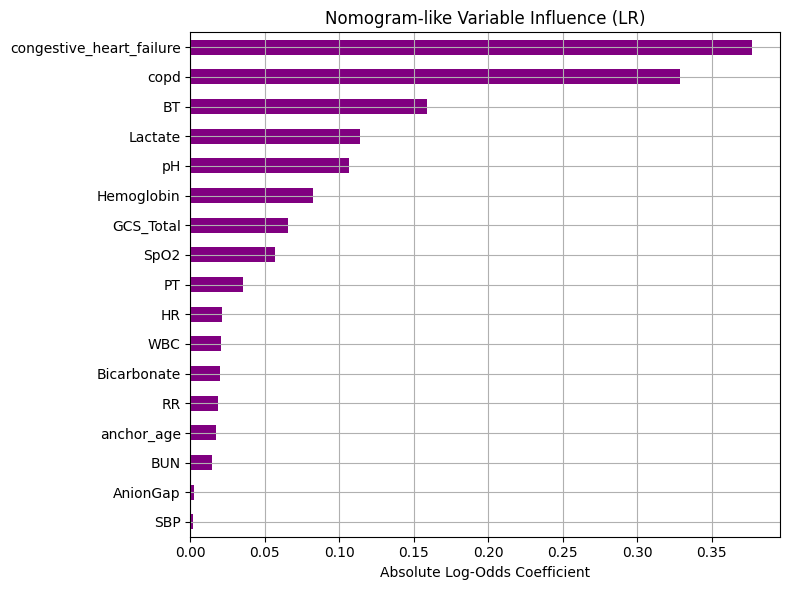

In [22]:
# Nomogram-like plot
coefs = multi_model.params[1:]  # Skip intercept
coefs_abs = coefs.abs().sort_values(ascending=True)

plt.figure(figsize=(8, 6))
coefs_abs.plot(kind='barh', color='purple')
plt.xlabel("Absolute Log-Odds Coefficient")
plt.title("Nomogram-like Variable Influence (LR)")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Step 6: Model Evaluation on Validation Set

✅ AUC: 0.7534


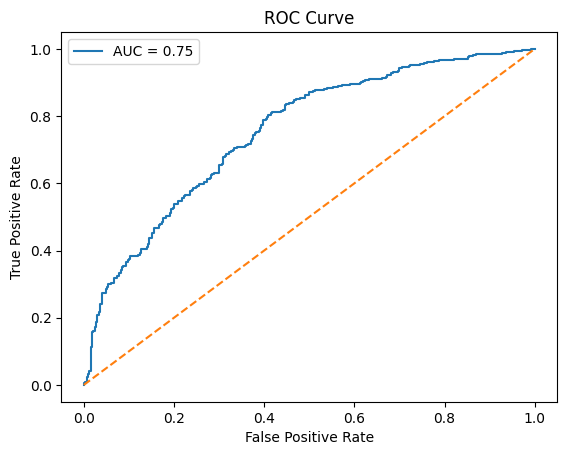

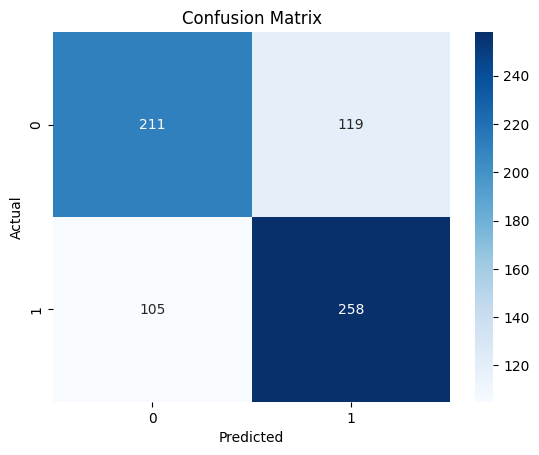

              precision    recall  f1-score   support

           0       0.67      0.64      0.65       330
           1       0.68      0.71      0.70       363

    accuracy                           0.68       693
   macro avg       0.68      0.68      0.68       693
weighted avg       0.68      0.68      0.68       693



In [31]:
# Predict on validation set
#X_val_final = sm.add_constant(X_val[significant_vars])
X_val_final = sm.add_constant(X_val[significant_vars].drop(columns=['INR']))
y_prob = multi_model.predict(X_val_final)
y_pred = (y_prob > 0.5).astype(int)

# ROC AUC
auc = roc_auc_score(y_val, y_prob)
print(f"✅ AUC: {auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# Classification report
print(classification_report(y_val, y_pred))

| Metric    | Class 0 (Survived) | Class 1 (Died) | Meaning                                       |
| --------- | ------------------ | -------------- | --------------------------------------------- |
| Precision | 0.67               | 0.68           | Of all predicted class, how many were correct |
| Recall    | 0.64               | 0.71           | Of all actual class, how many were caught     |
| F1-score  | 0.65               | 0.70           | Harmonic mean of precision & recall           |


On the validation set (n = 693), the logistic regression model achieved an AUC of 0.75, with a classification accuracy of 68%. It showed stronger performance in predicting mortality (recall = 0.71) compared to survival (recall = 0.64). The confusion matrix confirms that the model correctly identified 258 deaths and 211 survivors, suggesting clinically useful discrimination.

#### ROC + Calibration for LASSO (Training Set)

In [38]:
# # === Train Set ROC & Calibration ===
# X_train_final = sm.add_constant(X_train[significant_vars])
# y_prob_train = multi_model.predict(X_train_final)

# # ROC Curve
# fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
# auc_train = roc_auc_score(y_train, y_prob_train)

# plt.plot(fpr_train, tpr_train, label=f'Train AUC = {auc_train:.2f}', color='orange')
# plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
# plt.xlabel("1 - Specificity"); plt.ylabel("Sensitivity")
# plt.title("LASSO ROC (Train Set)"); plt.legend(); plt.grid(True); plt.show()

# # Calibration Curve (Train)
# from sklearn.calibration import calibration_curve
# prob_true_train, prob_pred_train = calibration_curve(y_train, y_prob_train, n_bins=10)

# plt.plot(prob_pred_train, prob_true_train, marker='o', label="Apparent")
# plt.plot([0, 1], [0, 1], linestyle='--', label="Ideal")
# plt.xlabel("Predicted Probability"); plt.ylabel("Observed Probability")
# plt.title("LASSO Calibration Curve (Train Set)")
# plt.grid(True); plt.legend(); plt.show()

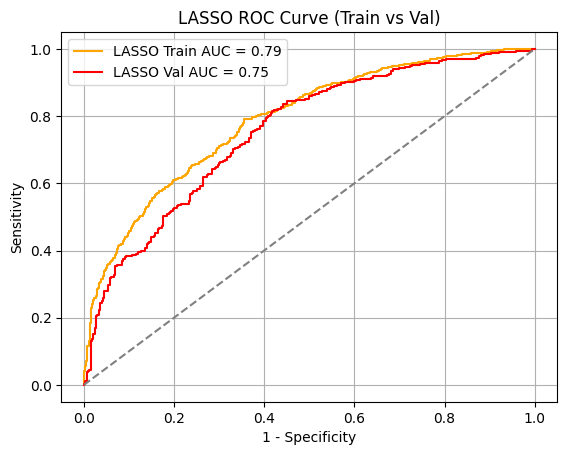

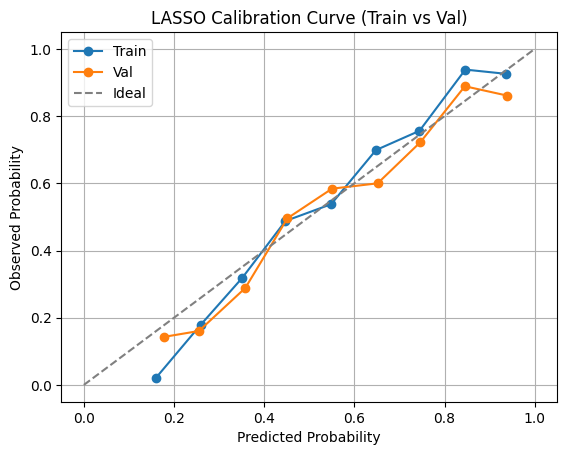

In [24]:
# --- LASSO (sklearn) Prediction Probabilities ---
y_prob_lasso_train = final_lasso.predict_proba(X_train_scaled)[:, 1]
y_prob_lasso_val = final_lasso.predict_proba(X_val_scaled)[:, 1]

# --- AUC Scores ---
auc_lasso_train = roc_auc_score(y_train, y_prob_lasso_train)
auc_lasso_val = roc_auc_score(y_val, y_prob_lasso_val)

# --- ROC Curves ---
fpr_lasso_train, tpr_lasso_train, _ = roc_curve(y_train, y_prob_lasso_train)
fpr_lasso_val, tpr_lasso_val, _ = roc_curve(y_val, y_prob_lasso_val)

# --- Plot LASSO ROC (Train vs Val) ---
plt.plot(fpr_lasso_train, tpr_lasso_train, label=f'LASSO Train AUC = {auc_lasso_train:.2f}', color='orange')
plt.plot(fpr_lasso_val, tpr_lasso_val, label=f'LASSO Val AUC = {auc_lasso_val:.2f}', color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("1 - Specificity"); plt.ylabel("Sensitivity")
plt.title("LASSO ROC Curve (Train vs Val)")
plt.legend(); plt.grid(True); plt.show()

# --- Calibration Curves ---
from sklearn.calibration import calibration_curve

prob_true_lasso_train, prob_pred_lasso_train = calibration_curve(y_train, y_prob_lasso_train, n_bins=10)
prob_true_lasso_val, prob_pred_lasso_val = calibration_curve(y_val, y_prob_lasso_val, n_bins=10)

# --- Plot LASSO Calibration (Train vs Val) ---
plt.plot(prob_pred_lasso_train, prob_true_lasso_train, marker='o', label='Train')
plt.plot(prob_pred_lasso_val, prob_true_lasso_val, marker='o', label='Val')
plt.plot([0, 1], [0, 1], linestyle='--', label='Ideal', color='gray')
plt.xlabel("Predicted Probability"); plt.ylabel("Observed Probability")
plt.title("LASSO Calibration Curve (Train vs Val)")
plt.legend(); plt.grid(True); plt.show()


##### LASSO Model Evaluation: Discrimination and Calibration
ROC Curve (Train vs Validation)
This plot compares the discriminative ability of the LASSO model on the training and validation datasets:
 * Train AUC = 0.79
 * Validation AUC = 0.75

AUC (Area Under the Curve) measures how well the model distinguishes between classes.
 * The slight drop in AUC from training to validation indicates mild overfitting, but the performance remains strong and generalizes reasonably well.

Calibration Curve (Train vs Validation)
 * This plot evaluates how well the predicted probabilities reflect actual outcomes:
 * The closer the line is to the 45° diagonal, the better the model’s probability estimates are calibrated.

Both training and validation curves are reasonably close to the ideal line, suggesting that the LASSO model produces reliable probability estimates for patient mortality risk.

#### ROC + Calibration for XGBoost

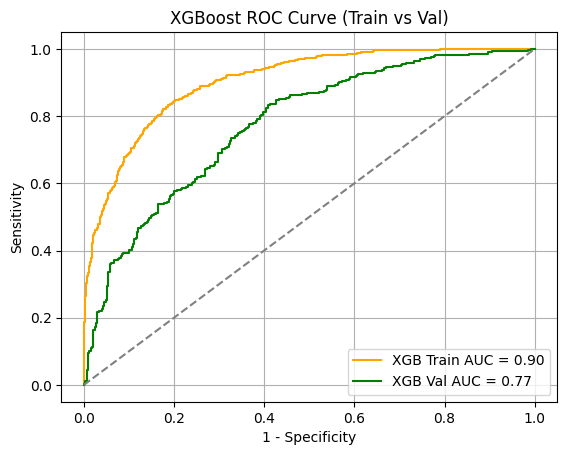

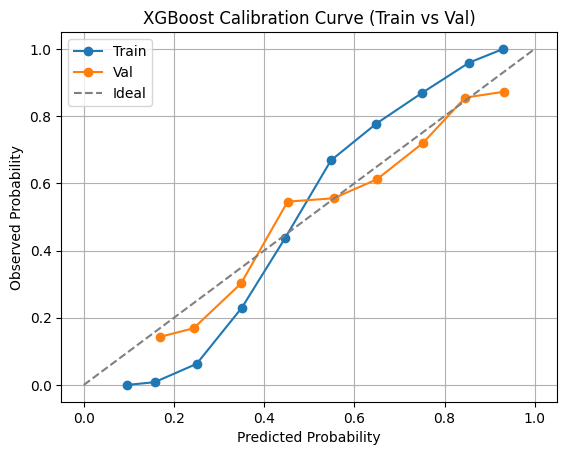

In [25]:
# --- XGBoost (sklearn) Prediction Probabilities ---
y_prob_xgb_train = xgb_model.predict_proba(X_train)[:, 1]
y_prob_xgb_val = xgb_model.predict_proba(X_val)[:, 1]

# --- AUC Scores ---
auc_xgb_train = roc_auc_score(y_train, y_prob_xgb_train)
auc_xgb_val = roc_auc_score(y_val, y_prob_xgb_val)

# --- ROC Curves ---
fpr_xgb_train, tpr_xgb_train, _ = roc_curve(y_train, y_prob_xgb_train)
fpr_xgb_val, tpr_xgb_val, _ = roc_curve(y_val, y_prob_xgb_val)

# --- Plot XGBoost ROC (Train vs Val) ---
plt.plot(fpr_xgb_train, tpr_xgb_train, label=f'XGB Train AUC = {auc_xgb_train:.2f}', color='orange')
plt.plot(fpr_xgb_val, tpr_xgb_val, label=f'XGB Val AUC = {auc_xgb_val:.2f}', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("1 - Specificity"); plt.ylabel("Sensitivity")
plt.title("XGBoost ROC Curve (Train vs Val)")
plt.legend(); plt.grid(True); plt.show()

# --- Calibration Curves ---
from sklearn.calibration import calibration_curve

prob_true_xgb_train, prob_pred_xgb_train = calibration_curve(y_train, y_prob_xgb_train, n_bins=10)
prob_true_xgb_val, prob_pred_xgb_val = calibration_curve(y_val, y_prob_xgb_val, n_bins=10)

# --- Plot XGBoost Calibration (Train vs Val) ---
plt.plot(prob_pred_xgb_train, prob_true_xgb_train, marker='o', label='Train')
plt.plot(prob_pred_xgb_val, prob_true_xgb_val, marker='o', label='Val')
plt.plot([0, 1], [0, 1], linestyle='--', label='Ideal', color='gray')
plt.xlabel("Predicted Probability"); plt.ylabel("Observed Probability")
plt.title("XGBoost Calibration Curve (Train vs Val)")
plt.legend(); plt.grid(True); plt.show()

##### XGBoost Model Evaluation: Discrimination and Calibration
ROC Curve (Train vs Validation)
This curve shows how well the XGBoost model distinguishes between patients who survived and those who didn’t:
 * Train AUC = 0.90
 * Validation AUC = 0.77

The model achieves excellent discrimination on the training set, but there's a drop in AUC on the validation set — a typical sign of mild overfitting. Still, an AUC of 0.77 on validation indicates strong generalization.

Calibration Curve (Train vs Validation)
This plot evaluates how well predicted probabilities match observed outcomes:
 * The training curve appears smoother, which is common due to the larger data used in training and the model's better fit.
 * However, the training line lies farther from the ideal diagonal, especially in some probability bins, suggesting that despite its high AUC, the model may be overconfident in its predictions.
 * The validation curve, while a bit less smooth, actually tracks the ideal diagonal more closely, indicating better-calibrated predictions on unseen data.

#### Step 7. NEWS2 Model (Simplified Benchmark)

✅ What is NEWS2?
The National Early Warning Score 2 (NEWS2) is a clinical tool for detecting early deterioration in patients. It’s based on 6 physiological parameters:

| Variable                  | Range (Values)                                | Points           |
| ------------------------- | --------------------------------------------- | ---------------- |
| **Respiratory Rate (RR)** | ≤8, 9–11, 12–20, 21–24, ≥25                   | 3, 1, 0, 2, 3    |
| **SpO2**                  | ≥96, 94–95, 92–93, ≤91                        | 0, 1, 2, 3       |
| **SBP**                   | ≤90, 91–100, 101–110, 111–219, ≥220           | 3, 2, 1, 0, 3    |
| **HR**                    | ≤40, 41–50, 51–90, 91–110, 111–130, ≥131      | 3, 1, 0, 1, 2, 3 |
| **Temperature (BT)**      | ≤35.0, 35.1–36.0, 36.1–38.0, 38.1–39.0, ≥39.1 | 3, 1, 0, 1, 2    |
| **Consciousness (GCS)**   | Altered or unresponsive (GCS < 15) = 3        | 3 if GCS < 15    |


| Vital Sign      | Danger if...          |
| --------------- | --------------------- |
| **RR**          | Too low OR too high   |
| **SpO₂**        | Only when too low     |
| **SBP**         | Very low OR very high |
| **HR**          | Too low OR too high   |
| **Temperature** | Too low OR too high   |


#### Python Implementation of NEWS2 Score

In [26]:
def calculate_news2_score(df):
    score = pd.Series(0, index=df.index)

    # RR
    rr = df['RR']
    score += np.select(
        [rr <= 8, rr.between(9, 11), rr.between(12, 20), rr.between(21, 24), rr >= 25],
        [3, 1, 0, 2, 3], default=0
    )

    # SpO2
    spo2 = df['SpO2']
    score += np.select(
        [spo2 >= 96, spo2.between(94, 95), spo2.between(92, 93), spo2 <= 91],
        [0, 1, 2, 3], default=0
    )

    # SBP
    sbp = df['SBP']
    score += np.select(
        [sbp <= 90, sbp.between(91, 100), sbp.between(101, 110), sbp.between(111, 219), sbp >= 220],
        [3, 2, 1, 0, 3], default=0
    )

    # HR
    hr = df['HR']
    score += np.select(
        [hr <= 40, hr.between(41, 50), hr.between(51, 90), hr.between(91, 110),
         hr.between(111, 130), hr >= 131],
        [3, 1, 0, 1, 2, 3], default=0
    )

    # Temperature
    temp = df['BT']
    score += np.select(
        [temp <= 35.0, temp.between(35.1, 36.0), temp.between(36.1, 38.0),
         temp.between(38.1, 39.0), temp >= 39.1],
        [3, 1, 0, 1, 2], default=0
    )

    # Consciousness via GCS (GCS < 15 means altered)
    gcs = df['GCS_Total']
    score += np.where(gcs < 15, 3, 0)

    return score

#### Evaluate NEWS2 as Model

In [27]:
# Calculate NEWS2 scores
news2_train = calculate_news2_score(X_train)
news2_val = calculate_news2_score(X_val)

# Fit logistic regression using NEWS2 score
news2_model = sm.Logit(y_train, sm.add_constant(news2_train)).fit()
print(news2_model.summary())

# Predict probabilities
y_prob_news2_train = news2_model.predict(sm.add_constant(news2_train))
y_prob_news2_val = news2_model.predict(sm.add_constant(news2_val))

# AUC
auc_news2_train = roc_auc_score(y_train, y_prob_news2_train)
auc_news2_val = roc_auc_score(y_val, y_prob_news2_val)
print(f"✅ NEWS2 AUC: Train = {auc_news2_train:.4f} | Val = {auc_news2_val:.4f}")

Optimization terminated successfully.
         Current function value: 0.645082
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        survival_status   No. Observations:                 1614
Model:                          Logit   Df Residuals:                     1612
Method:                           MLE   Df Model:                            1
Date:                Mon, 21 Jul 2025   Pseudo R-squ.:                 0.06793
Time:                        19:31:45   Log-Likelihood:                -1041.2
converged:                       True   LL-Null:                       -1117.0
Covariance Type:            nonrobust   LLR p-value:                 7.149e-35
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6775      0.162    -10.341      0.000      -1.995      -1.360
0              0.2562      0.

To benchmark the performance of standard clinical tools, we fit a logistic regression model using only the NEWS2 score as the predictor for in-hospital mortality.

📊 Regression Summary:
 * The coefficient (0.256) is statistically significant (p < 0.001), indicating that higher NEWS2 scores are associated with increased mortality risk.
 * The pseudo R² = 0.068, suggesting that NEWS2 explains only a small portion of the variability in survival outcomes.

🎯 Discrimination Performance:
| Metric  | Training Set | Validation Set |
| ------- | ------------ | -------------- |
| **AUC** | 0.6645       | 0.6727         |

 * These AUC values indicate moderate discriminatory power.
 * As expected, the NEWS2 model performs worse than data-driven models like LASSO, Logistic Regression (with multiple variables), and XGBoost, but still captures some predictive signal.


#### Plot ROC & Calibration (Train & Val)

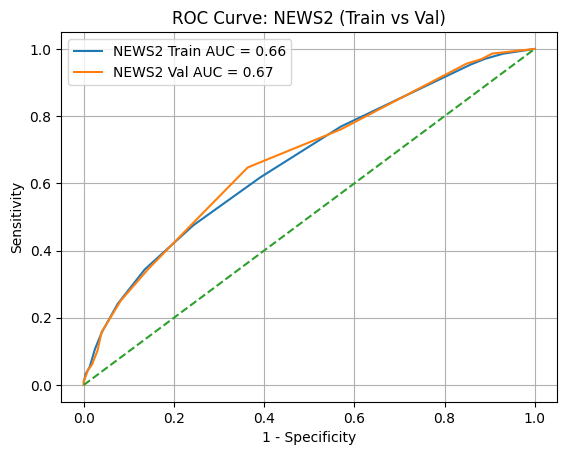

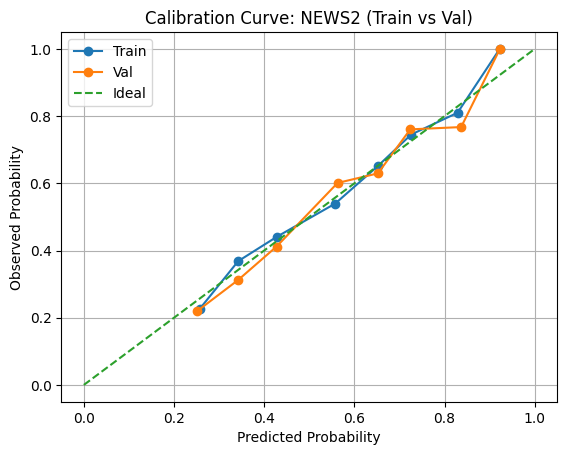

In [28]:
# ROC Curve
fpr_n_train, tpr_n_train, _ = roc_curve(y_train, y_prob_news2_train)
fpr_n_val, tpr_n_val, _ = roc_curve(y_val, y_prob_news2_val)

plt.plot(fpr_n_train, tpr_n_train, label=f'NEWS2 Train AUC = {auc_news2_train:.2f}')
plt.plot(fpr_n_val, tpr_n_val, label=f'NEWS2 Val AUC = {auc_news2_val:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('1 - Specificity'); plt.ylabel('Sensitivity'); plt.grid(True)
plt.legend(); plt.title("ROC Curve: NEWS2 (Train vs Val)")
plt.show()

# Calibration
for label, y_true, y_prob in [('Train', y_train, y_prob_news2_train), ('Val', y_val, y_prob_news2_val)]:
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=label)

plt.plot([0, 1], [0, 1], linestyle='--', label='Ideal')
plt.title("Calibration Curve: NEWS2 (Train vs Val)")
plt.xlabel("Predicted Probability"); plt.ylabel("Observed Probability")
plt.legend(); plt.grid(True); plt.show()

##### NEWS2 Calibration and Discrimination Analysis
ROC Curve (Train vs Validation)
 * The NEWS2 model achieved AUCs of 0.66 (Train) and 0.67 (Validation), indicating modest discriminatory ability.
 * While this performance is lower than LASSO and XGBoost, it still demonstrates consistency across datasets, with no major overfitting.

Calibration Curve (Train vs Validation)
 * Interestingly, the NEWS2 model shows closer alignment to the ideal diagonal line in both training and validation sets compared to LASSO and XGBoost.
 * This suggests that NEWS2's predicted probabilities are better calibrated — i.e., they more accurately reflect actual outcome likelihoods.
 * In clinical settings, better calibration is often desirable, especially when using predicted probabilities for decision-making.

#### ROC Curve Comparison (Final)

In [29]:
# plt.plot(fpr_val, tpr_val, label=f'LASSO Val AUC = {auc_val:.2f}', color='red')
# plt.plot(fpr_xgb_val, tpr_xgb_val, label=f'XGBoost Val AUC = {auc_xgb_val:.2f}', color='green')
# plt.plot(fpr_n_val, tpr_n_val, label=f'NEWS2 Val AUC = {auc_news2_val:.2f}', color='blue')
# plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# plt.xlabel("1 - Specificity"); plt.ylabel("Sensitivity")
# plt.title("Model Comparison: ROC Curves (Validation)")
# plt.legend(); plt.grid(True); plt.show()

#### Decision Curve Analysis (DCA) (AFTER all models’ validation probs are computed)

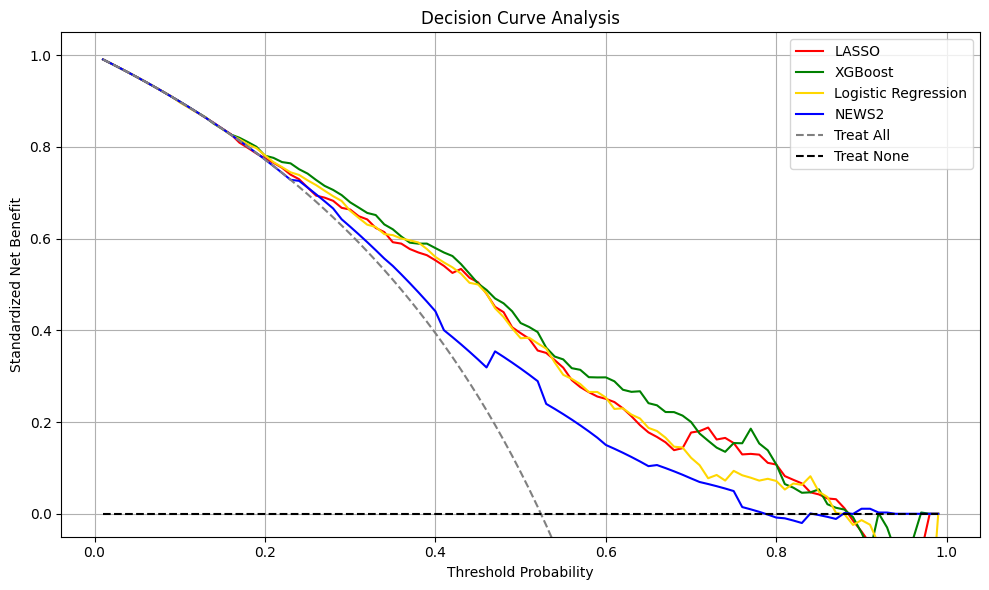

In [32]:
def standardized_net_benefit(y_true, y_prob, thresholds):
    n = len(y_true)
    prevalence = np.mean(y_true)
    snb = []

    for t in thresholds:
        pred_positive = y_prob >= t
        tp = np.sum((y_true == 1) & pred_positive)
        fp = np.sum((y_true == 0) & pred_positive)
        nb = (tp / n) - (fp / n) * (t / (1 - t))
        snb.append(nb / prevalence if prevalence > 0 else 0)

    return np.array(snb)

# Thresholds from 0.01 to 0.99
thresholds = np.linspace(0.01, 0.99, 99)

# Calculate standardized net benefit for each model
snb_lasso = standardized_net_benefit(y_val, y_prob_lasso_val, thresholds)
snb_xgb = standardized_net_benefit(y_val, y_prob_xgb_val, thresholds)
# snb_lr = standardized_net_benefit(y_val, y_pred, thresholds)
snb_lr = standardized_net_benefit(y_val, y_prob, thresholds)
snb_news2 = standardized_net_benefit(y_val, y_prob_news2_val, thresholds)

# Treat all and treat none
# treat_all = [1 - t / (1 - t) for t in thresholds]
# treat_all_std = np.array(treat_all) / np.mean(y_val)  # Standardize
prevalence = np.mean(y_val)
treat_all = prevalence - (1 - prevalence) * thresholds / (1 - thresholds)
treat_all_std = treat_all / prevalence
treat_none = np.zeros_like(thresholds)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, snb_lasso, label="LASSO", color='red')
plt.plot(thresholds, snb_xgb, label="XGBoost", color='green')
plt.plot(thresholds, snb_lr, label="Logistic Regression", color='gold')
plt.plot(thresholds, snb_news2, label="NEWS2", color='blue')
plt.plot(thresholds, treat_all_std, color='gray', linestyle='--', label='Treat All')
plt.plot(thresholds, treat_none, color='black', linestyle='--', label='Treat None')

# Labels & Grid
plt.xlabel("Threshold Probability")
plt.ylabel("Standardized Net Benefit")
plt.title("Decision Curve Analysis")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

##### The DCA compares the clinical usefulness of four models (LASSO, XGBoost, Logistic Regression, and NEWS2) across a range of decision thresholds (from 0.01 to 0.99). The y-axis represents the standardized net benefit of using each model to decide whether to intervene (e.g., trigger a clinical alert).
 * The grey dashed line ("Treat All") assumes every patient will die → used as a naive strategy.
 * The black dashed line ("Treat None") assumes no patient will die → another naive baseline.
 * A model adds value if its curve lies above both "Treat All" and "Treat None".
 * According to the graph:
   * All four models offer clinical net benefit over “Treat All” and “Treat None” within threshold probabilities of approximately 0.18 to 0.86.
   * Among the models, the LASSO, XGBoost and Logistic Regression models consistently show higher net benefit, especially in the threshold range ~0.3–0.6, suggesting better clinical utility.
   * The NEWS2 model shows lower net benefit compared to others, especially as threshold probability increases.

🔍 Clinical implication: In practice, if a clinician would only act (e.g., trigger intervention) when the predicted mortality risk is between 18% and 86%, then using any of these models (LASSO, XGBoost or Logistic Regression) offers better decisions than treating everyone or no one.

#### ROC Comparison (Figure 8B)

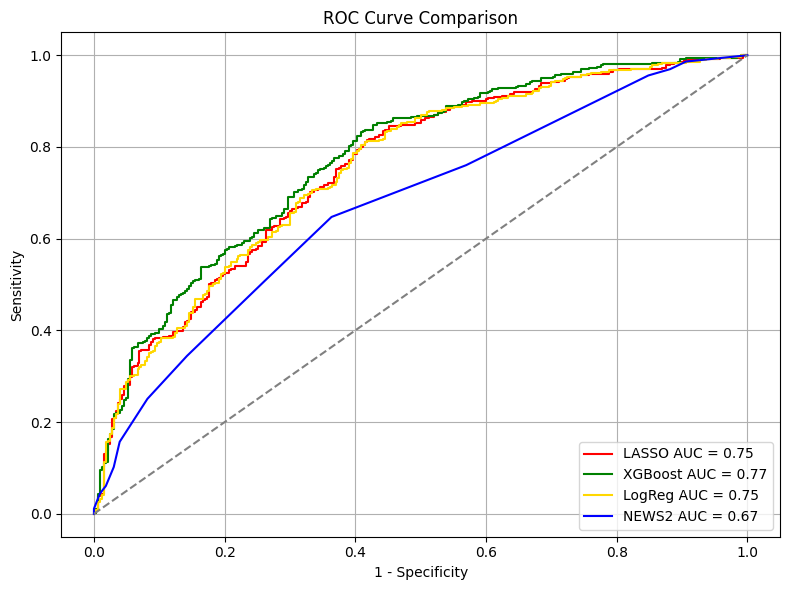

In [33]:
# --- Recalculate AUCs if needed ---
auc_lasso = roc_auc_score(y_val, y_prob_lasso_val)
auc_xgb = roc_auc_score(y_val, y_prob_xgb_val)
auc_lr = roc_auc_score(y_val, y_prob)  # multivariate LR
auc_news2 = roc_auc_score(y_val, y_prob_news2_val)

# --- ROC Curves ---
fpr_lasso, tpr_lasso, _ = roc_curve(y_val, y_prob_lasso_val)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_prob_xgb_val)
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_prob)
fpr_news2, tpr_news2, _ = roc_curve(y_val, y_prob_news2_val)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_lasso, tpr_lasso, label=f"LASSO AUC = {auc_lasso:.2f}", color='red')
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost AUC = {auc_xgb:.2f}", color='green')
plt.plot(fpr_lr, tpr_lr, label=f"LogReg AUC = {auc_lr:.2f}", color='gold')
plt.plot(fpr_news2, tpr_news2, label=f"NEWS2 AUC = {auc_news2:.2f}", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel("1 - Specificity")
plt.ylabel("Sensitivity")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

##### This ROC curve compares the predictive performance of four models: LASSO, XGBoost, Logistic Regression (LogReg), and NEWS2, based on their ability to distinguish between survivors and non-survivors in the validation dataset.
 * XGBoost achieved the highest AUC (0.77), indicating slightly better overall discrimination performance.
 * LASSO and Logistic Regression models followed closely with AUCs of 0.75, showing comparable predictive accuracy.
 * NEWS2, a traditional scoring system, had the lowest AUC (0.67), suggesting weaker predictive power in this cohort.

The diagonal gray dashed line represents a random guess (AUC = 0.5). All models outperform this baseline, but machine learning models consistently show better discrimination than the NEWS2 score.

Note: The validation set was used to fairly evaluate model performance on unseen data, avoiding overfitting or optimism bias.